# Notebook 02-CIC — Train 6 Canonical Models on CIC-IDS2017

**Project:** Calibrated and Stability-Aware Explainable Intrusion Detection
**Author:** Md Anas Biswas, University of Portsmouth
**Dataset:** CIC-IDS2017 (200K subsample)

Trains the 6 canonical models with the same hyperparameters as NSL-KDD for direct cross-dataset comparison:
- `rf_binary_cw`, `xgb_binary_cw`, `dnn_binary_cw` (binary, class-weighted)
- `rf_5class_smote`, `xgb_5class_smote`, `dnn_5class_smote` (5-class, SMOTE)

**Note on U2R:** CIC-IDS2017 has only 36 U2R-equivalent samples (Infiltration class). The model will train on these but expected F1 ≈ 0 on test. This is documented as a known limitation, consistent with Engelen WTMC-2021's observations on CIC-IDS2017 quality.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
REPO = '/content/drive/MyDrive/XIDS_Research/xids-research'
os.chdir(REPO)

for f in ['.gitconfig', '.git-credentials']:
    src = f'/content/drive/MyDrive/XIDS_Research/{f}'
    if os.path.exists(src):
        shutil.copy(src, f'/root/{f}')
        if f == '.git-credentials':
            os.chmod(f'/root/{f}', 0o600)

!git pull
print(f'✓ Ready in: {os.getcwd()}')

Mounted at /content/drive
Already up to date.
✓ Ready in: /content/drive/MyDrive/XIDS_Research/xids-research


In [2]:
!pip install -q xgboost imbalanced-learn==0.12.4 --upgrade 2>&1 | tail -3
print('✓ Packages ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 6.6 MB/s eta 0:00:00
✓ Packages ready


In [3]:
import numpy as np
import pandas as pd
import json, pickle, time
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [4]:
# Paths — CIC-IDS2017 has its own subfolder
PROCESSED = Path(REPO) / 'data' / 'processed' / 'cic_ids2017'
MODELS_DIR = Path(REPO) / 'models' / 'cic_ids2017'
PREDS_DIR = MODELS_DIR / 'predictions'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PREDS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = Path(REPO) / 'results' / 'figures'
TABLES_DIR = Path(REPO) / 'results' / 'tables'

X_train = np.load(PROCESSED / 'X_train.npy')
X_test = np.load(PROCESSED / 'X_test.npy')
y_train_b = np.load(PROCESSED / 'y_train_binary.npy')
y_test_b = np.load(PROCESSED / 'y_test_binary.npy')
y_train_5 = np.load(PROCESSED / 'y_train_5class.npy')
y_test_5 = np.load(PROCESSED / 'y_test_5class.npy')

with open(PROCESSED / 'class_mappings.json') as f:
    class_info = json.load(f)
INT_TO_CATEGORY = {int(k): v for k, v in class_info['multiclass_5'].items()}
CLASS_NAMES_BINARY = ['Normal', 'Attack']
CLASS_NAMES_5 = [INT_TO_CATEGORY[i] for i in range(5)]

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Train binary: {np.bincount(y_train_b)}')
print(f'Train 5-class: {np.bincount(y_train_5)}')

X_train: (160024, 78), X_test: (40007, 78)
Train binary: [128608  31416]
Train 5-class: [128608  21502   8991    894     29]


---
## Step 1 — SMOTE for 5-class

U2R has 28 train samples, which is enough for default `k_neighbors=5`. We use `k_neighbors=min(5, 28-1)` to be safe.

In [5]:
# Compute the safe k_neighbors based on minimum class size
min_class_size = np.min(np.bincount(y_train_5))
k_neighbors = min(5, min_class_size - 1)
print(f'Min class size: {min_class_size}, using k_neighbors={k_neighbors}')

smote = SMOTE(random_state=SEED, n_jobs=-1, k_neighbors=k_neighbors)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train_5)

print(f'\nBefore SMOTE:')
for i in range(5):
    print(f'  {CLASS_NAMES_5[i]:8s}: {np.sum(y_train_5==i):>7,}')
print(f'\nAfter SMOTE:')
for i in range(5):
    print(f'  {CLASS_NAMES_5[i]:8s}: {np.sum(y_train_smote==i):>7,}')

Min class size: 29, using k_neighbors=5


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/imblearn/over_sampling/_smote/base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(



Before SMOTE:
  Normal  : 128,608
  DoS     :  21,502
  Probe   :   8,991
  R2L     :     894
  U2R     :      29

After SMOTE:
  Normal  : 128,608
  DoS     : 128,608
  Probe   : 128,608
  R2L     : 128,608
  U2R     : 128,608


---
## Step 2 — Evaluation helper

In [6]:
def evaluate(y_true, y_pred, y_proba, class_names, model_name):
    n_classes = len(class_names)
    f1_pc = f1_score(y_true, y_pred, average=None, zero_division=0, labels=np.arange(n_classes))
    return {
        'model': model_name,
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'f1_macro': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'f1_weighted': float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'mcc': float(matthews_corrcoef(y_true, y_pred)),
        'f1_per_class': {class_names[i]: float(f1_pc[i]) for i in range(n_classes)},
        'confusion_matrix': confusion_matrix(y_true, y_pred, labels=np.arange(n_classes)).tolist(),
    }

def print_metrics(m):
    print(f'  Acc={m["accuracy"]:.4f}  MacroF1={m["f1_macro"]:.4f}  MCC={m["mcc"]:.4f}')
    for cn, s in m['f1_per_class'].items():
        print(f'    {cn:8s}: {s:.4f}')

ALL_METRICS = {}

---
## Step 3 — Random Forest (2 models: binary CW + 5-class SMOTE)

In [7]:
# Binary CW
print('--- rf_binary_cw ---')
t0 = time.time()
rf_b = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED, class_weight='balanced')
rf_b.fit(X_train, y_train_b)
print(f'  Trained in {time.time()-t0:.1f}s')
y_pred = rf_b.predict(X_test); y_proba = rf_b.predict_proba(X_test)
m = evaluate(y_test_b, y_pred, y_proba, CLASS_NAMES_BINARY, 'rf_binary_cw')
ALL_METRICS['rf_binary_cw'] = m; print_metrics(m)
with open(MODELS_DIR / 'rf_binary_cw.pkl', 'wb') as f: pickle.dump(rf_b, f)
np.save(PREDS_DIR / 'rf_binary_cw_proba.npy', y_proba)
np.save(PREDS_DIR / 'rf_binary_cw_pred.npy', y_pred)
del rf_b

# 5-class SMOTE
print('\n--- rf_5class_smote ---')
t0 = time.time()
rf_5 = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED)
rf_5.fit(X_train_smote, y_train_smote)
print(f'  Trained in {time.time()-t0:.1f}s')
y_pred = rf_5.predict(X_test); y_proba = rf_5.predict_proba(X_test)
m = evaluate(y_test_5, y_pred, y_proba, CLASS_NAMES_5, 'rf_5class_smote')
ALL_METRICS['rf_5class_smote'] = m; print_metrics(m)
with open(MODELS_DIR / 'rf_5class_smote.pkl', 'wb') as f: pickle.dump(rf_5, f)
np.save(PREDS_DIR / 'rf_5class_smote_proba.npy', y_proba)
np.save(PREDS_DIR / 'rf_5class_smote_pred.npy', y_pred)
del rf_5

--- rf_binary_cw ---
  Trained in 17.8s
  Acc=0.9982  MacroF1=0.9971  MCC=0.9942
    Normal  : 0.9989
    Attack  : 0.9953

--- rf_5class_smote ---
  Trained in 104.2s
  Acc=0.9982  MacroF1=0.9752  MCC=0.9946
    Normal  : 0.9989
    DoS     : 0.9970
    Probe   : 0.9949
    R2L     : 0.9623
    U2R     : 0.9231


---
## Step 4 — XGBoost (2 models)

In [8]:
XGB_HP = dict(n_estimators=300, max_depth=8, learning_rate=0.1,
              subsample=0.9, colsample_bytree=0.9, tree_method='hist',
              random_state=SEED, n_jobs=-1)

# Binary CW
print('--- xgb_binary_cw ---')
t0 = time.time()
classes_b = np.unique(y_train_b)
cw_b = compute_class_weight('balanced', classes=classes_b, y=y_train_b)
sw_b = np.array([cw_b[c] for c in y_train_b])
xgb_b = xgb.XGBClassifier(**XGB_HP, objective='binary:logistic', eval_metric='logloss')
xgb_b.fit(X_train, y_train_b, sample_weight=sw_b)
print(f'  Trained in {time.time()-t0:.1f}s')
y_pred = xgb_b.predict(X_test); y_proba = xgb_b.predict_proba(X_test)
m = evaluate(y_test_b, y_pred, y_proba, CLASS_NAMES_BINARY, 'xgb_binary_cw')
ALL_METRICS['xgb_binary_cw'] = m; print_metrics(m)
with open(MODELS_DIR / 'xgb_binary_cw.pkl', 'wb') as f: pickle.dump(xgb_b, f)
np.save(PREDS_DIR / 'xgb_binary_cw_proba.npy', y_proba)
np.save(PREDS_DIR / 'xgb_binary_cw_pred.npy', y_pred)
del xgb_b

# 5-class SMOTE
print('\n--- xgb_5class_smote ---')
t0 = time.time()
xgb_5 = xgb.XGBClassifier(**XGB_HP, objective='multi:softprob', num_class=5, eval_metric='mlogloss')
xgb_5.fit(X_train_smote, y_train_smote)
print(f'  Trained in {time.time()-t0:.1f}s')
y_pred = xgb_5.predict(X_test); y_proba = xgb_5.predict_proba(X_test)
m = evaluate(y_test_5, y_pred, y_proba, CLASS_NAMES_5, 'xgb_5class_smote')
ALL_METRICS['xgb_5class_smote'] = m; print_metrics(m)
with open(MODELS_DIR / 'xgb_5class_smote.pkl', 'wb') as f: pickle.dump(xgb_5, f)
np.save(PREDS_DIR / 'xgb_5class_smote_proba.npy', y_proba)
np.save(PREDS_DIR / 'xgb_5class_smote_pred.npy', y_pred)
del xgb_5

--- xgb_binary_cw ---
  Trained in 4.3s
  Acc=0.9990  MacroF1=0.9983  MCC=0.9967
    Normal  : 0.9993
    Attack  : 0.9973

--- xgb_5class_smote ---
  Trained in 82.6s
  Acc=0.9989  MacroF1=0.9803  MCC=0.9966
    Normal  : 0.9993
    DoS     : 0.9982
    Probe   : 0.9969
    R2L     : 0.9736
    U2R     : 0.9333


---
## Step 5 — DNN (2 models)

In [9]:
class MLP(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=(256, 128, 64, 32), dropout=0.3):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

DNN_HP = dict(hidden=(256,128,64,32), dropout=0.3, batch_size=512, epochs=30, lr=1e-3, weight_decay=1e-5)

def train_dnn(X_tr, y_tr, X_te, y_te, class_names, name, use_class_weight):
    print(f'\n--- {name} ---')
    n_classes = len(class_names)
    torch.manual_seed(SEED)
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(DEVICE)
    y_tr_t = torch.tensor(y_tr, dtype=torch.long).to(DEVICE)
    X_te_t = torch.tensor(X_te, dtype=torch.float32).to(DEVICE)
    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=DNN_HP['batch_size'], shuffle=True)
    if use_class_weight:
        cl = np.unique(y_tr)
        cw = compute_class_weight('balanced', classes=cl, y=y_tr)
        criterion = nn.CrossEntropyLoss(weight=torch.tensor(cw, dtype=torch.float32).to(DEVICE))
    else:
        criterion = nn.CrossEntropyLoss()
    model = MLP(X_tr.shape[1], n_classes, hidden=DNN_HP['hidden'], dropout=DNN_HP['dropout']).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=DNN_HP['lr'], weight_decay=DNN_HP['weight_decay'])
    t0 = time.time()
    model.train()
    for epoch in range(1, DNN_HP['epochs']+1):
        epoch_loss = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward(); optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        epoch_loss /= len(loader.dataset)
        if epoch == 1 or epoch % 10 == 0 or epoch == DNN_HP['epochs']:
            print(f'  Epoch {epoch:>2}/{DNN_HP["epochs"]}  loss={epoch_loss:.4f}')
    print(f'  Trained in {time.time()-t0:.1f}s')
    model.eval()
    with torch.no_grad():
        logits = model(X_te_t)
        y_proba = torch.softmax(logits, dim=1).cpu().numpy()
        y_pred = y_proba.argmax(axis=1)
    m = evaluate(y_te, y_pred, y_proba, class_names, name)
    print_metrics(m)
    torch.save({
        'state_dict': model.state_dict(),
        'in_dim': X_tr.shape[1], 'n_classes': n_classes,
        'hidden': list(DNN_HP['hidden']), 'dropout': DNN_HP['dropout'],
    }, MODELS_DIR / f'{name}.pt')
    np.save(PREDS_DIR / f'{name}_proba.npy', y_proba)
    np.save(PREDS_DIR / f'{name}_pred.npy', y_pred)
    return m

ALL_METRICS['dnn_binary_cw'] = train_dnn(
    X_train, y_train_b, X_test, y_test_b, CLASS_NAMES_BINARY, 'dnn_binary_cw', use_class_weight=True
)
ALL_METRICS['dnn_5class_smote'] = train_dnn(
    X_train_smote, y_train_smote, X_test, y_test_5, CLASS_NAMES_5, 'dnn_5class_smote', use_class_weight=False
)


--- dnn_binary_cw ---
  Epoch  1/30  loss=0.1869
  Epoch 10/30  loss=0.0780
  Epoch 20/30  loss=0.0686
  Epoch 30/30  loss=0.0646
  Trained in 61.4s
  Acc=0.9713  MacroF1=0.9566  MCC=0.9160
    Normal  : 0.9818
    Attack  : 0.9313

--- dnn_5class_smote ---
  Epoch  1/30  loss=0.1881
  Epoch 10/30  loss=0.0516
  Epoch 20/30  loss=0.0451
  Epoch 30/30  loss=0.0428
  Trained in 239.9s
  Acc=0.9643  MacroF1=0.7920  MCC=0.9043
    Normal  : 0.9774
    DoS     : 0.9497
    Probe   : 0.9119
    R2L     : 0.5057
    U2R     : 0.6154


---
## Step 6 — Comparison table + save

In [10]:
rows = []
for name, m in ALL_METRICS.items():
    rows.append({
        'Model': name,
        'Accuracy': m['accuracy'],
        'Macro F1': m['f1_macro'],
        'MCC': m['mcc'],
        **{f"F1_{c}": s for c, s in m['f1_per_class'].items()},
    })
df = pd.DataFrame(rows)
df.to_csv(TABLES_DIR / 'cic_model_comparison.csv', index=False)

print('CIC-IDS2017 — 6 canonical models')
print('=' * 90)
print(df.to_string(index=False, float_format='%.4f'))
print('=' * 90)

with open(MODELS_DIR / 'metrics.json', 'w') as f:
    json.dump(ALL_METRICS, f, indent=2)
print(f'\n✓ Saved {len(ALL_METRICS)} model artifacts to {MODELS_DIR}')

CIC-IDS2017 — 6 canonical models
           Model  Accuracy  Macro F1    MCC  F1_Normal  F1_Attack  F1_DoS  F1_Probe  F1_R2L  F1_U2R
    rf_binary_cw    0.9982    0.9971 0.9942     0.9989     0.9953     NaN       NaN     NaN     NaN
 rf_5class_smote    0.9982    0.9752 0.9946     0.9989        NaN  0.9970    0.9949  0.9623  0.9231
   xgb_binary_cw    0.9990    0.9983 0.9967     0.9993     0.9973     NaN       NaN     NaN     NaN
xgb_5class_smote    0.9989    0.9803 0.9966     0.9993        NaN  0.9982    0.9969  0.9736  0.9333
   dnn_binary_cw    0.9713    0.9566 0.9160     0.9818     0.9313     NaN       NaN     NaN     NaN
dnn_5class_smote    0.9643    0.7920 0.9043     0.9774        NaN  0.9497    0.9119  0.5057  0.6154

✓ Saved 6 model artifacts to /content/drive/MyDrive/XIDS_Research/xids-research/models/cic_ids2017


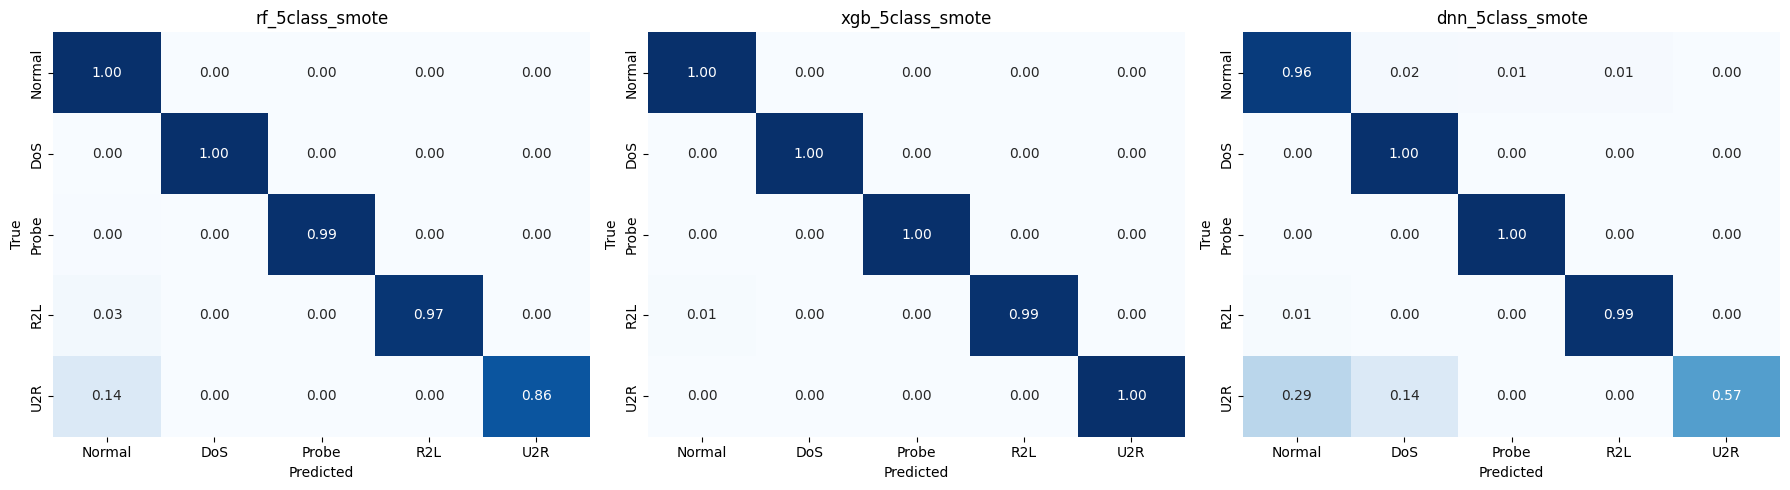

In [11]:
# Confusion matrices for 5-class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name in zip(axes, ['rf_5class_smote', 'xgb_5class_smote', 'dnn_5class_smote']):
    cm = np.array(ALL_METRICS[name]['confusion_matrix'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES_5, yticklabels=CLASS_NAMES_5,
                cbar=False, ax=ax, vmin=0, vmax=1)
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(FIG_DIR / 'cic_confusion_matrices_5class.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Commit
os.chdir(REPO)
!git add notebooks/02_cic_train_models.ipynb
!git add results/
!git status --short
!git commit -m 'Notebook 02-CIC: 6 canonical models trained on CIC-IDS2017'
!git push

Refresh index: 100% (54/54), done.
 M notebooks/01_cic_data_exploration.ipynb
A  notebooks/02_cic_train_models.ipynb
 M notebooks/05_stability_tests.ipynb
 M notebooks/06_shap_agreement.ipynb
 M notebooks/07_scts_v2.ipynb
 M notebooks/08_llm_alerts.ipynb
A  results/figures/cic_confusion_matrices_5class.png
A  results/tables/cic_model_comparison.csv
?? calibrators/
?? models/
[main bcd9602] Notebook 02-CIC: 6 canonical models trained on CIC-IDS2017
 3 files changed, 8 insertions(+)
 create mode 100644 notebooks/02_cic_train_models.ipynb
 create mode 100644 results/figures/cic_confusion_matrices_5class.png
 create mode 100644 results/tables/cic_model_comparison.csv
Enumerating objects: 14, done.
Counting objects: 100% (14/14), done.
Delta compression using up to 8 threads
Compressing objects: 100% (9/9), done.
Writing objects: 100% (9/9), 63.26 KiB | 3.72 MiB/s, done.
Total 9 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects

## Summary

**Done:**
- ✓ Trained 6 canonical models on CIC-IDS2017 (200K subsample)
- ✓ Same hyperparameters as NSL-KDD for direct comparison
- ✓ SMOTE for 5-class imbalance, class-weights for binary
- ✓ Saved models + predictions + metrics
- ✓ Confusion matrices for 5-class

**Expected patterns:**
- Accuracy ~0.95+ (CIC-IDS2017 is easier than NSL-KDD official split)
- U2R F1 ≈ 0 (only 36 samples, expected)
- All other classes should have F1 > 0.85

**Next:** Notebook 03-CIC (calibration with the test-set 50/50 split methodology).
